Analyzing British Airline Customer Booking Prediction
-

Customers are more empowered than ever because they have access to a wealth of information at their fingertips. This is one of the reasons the buying cycle is very different to what it used to be. Today, if you’re hoping that a customer purchases your flights or holidays as they come into the airport, you’ve already lost! Being reactive in this situation is not ideal; airlines must be proactive in order to acquire customers before they embark on their holiday.

This is possible with the use of data and predictive models. The most important factor with a predictive model is the quality of the data you use to train the machine learning algorithms. For this task, you must manipulate and prepare the provided customer booking data so that you can build a high-quality predictive model.

With your predictive model, it is important to interpret the results in order to understand how “predictive” the data really was and whether we can feasibly use it to predict the target outcome (customers buying holidays). Therefore, you should evaluate the model’s performance and output how each variable contributes to the predictive model’s power.

Importing Libraries and Loading Dataset
-

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

In [2]:
customer_booking = pd.read_csv("../Dataset/customer_booking.csv", encoding="latin1")
customer_booking.head()


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


Checking for Missing value and Describing the data
-

In [3]:
customer_booking.isnull().sum().sort_values(ascending=False)

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

There are no missing values in the dataset

In [4]:
print(customer_booking.info())
customer_booking.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


Checking for Duplicate Columns
-

In [5]:
customer_booking.duplicated().sort_index(ascending=True)
customer_booking.drop_duplicates(inplace=True)

Found 719 duplicated rows and dropped them

Data Visualization
-

In [6]:
sales_channel = customer_booking['sales_channel'].value_counts().reset_index()

sales_channel

,sales_channel,count
0,Internet,43917
1,Mobile,5364


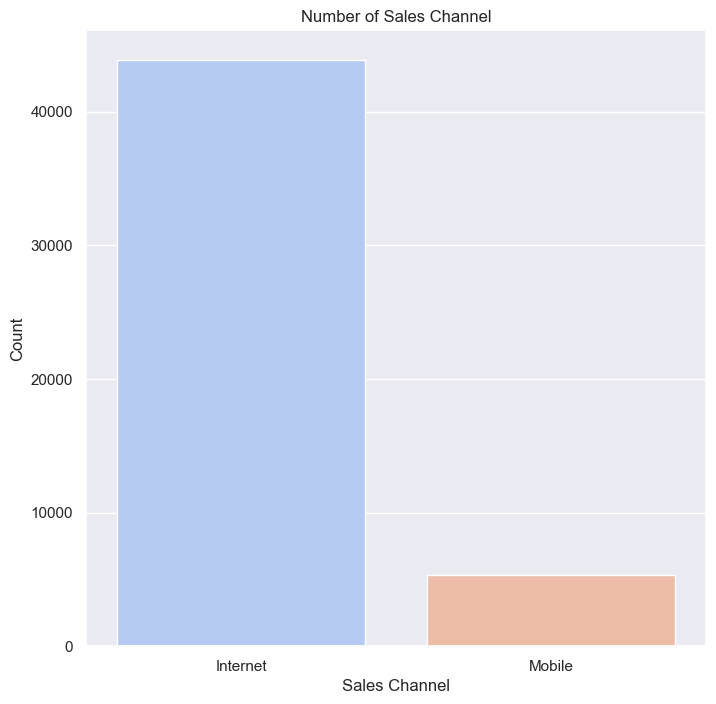

In [7]:
plt.figure(figsize=(8, 8))
sns.barplot(data = sales_channel, x='sales_channel', y='count', palette='coolwarm', hue='sales_channel')
plt.xlabel('Sales Channel')
plt.ylabel('Count')
plt.title('Number of Sales Channel')
plt.show()

In [8]:
trip_type = customer_booking['trip_type'].value_counts().reset_index()

trip_type

,trip_type,count
0,RoundTrip,48779
1,OneWay,386
2,CircleTrip,116


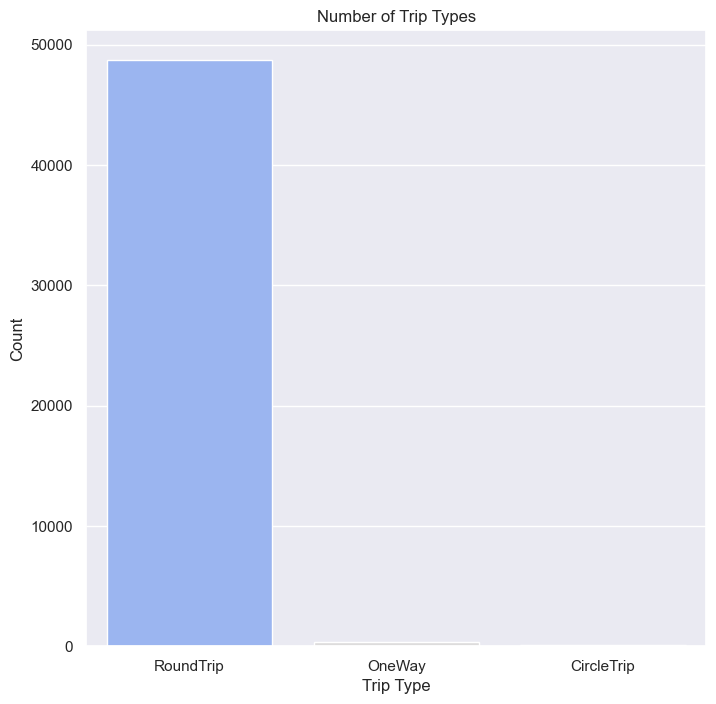

In [9]:
plt.figure(figsize=(8, 8))
sns.barplot(data = trip_type, x='trip_type', y='count', palette='coolwarm', hue='trip_type')
plt.xlabel('Trip Type')
plt.ylabel('Count')
plt.title('Number of Trip Types')
plt.show()

In [10]:
flight_day = customer_booking['flight_day'].value_counts().reset_index()

flight_day

,flight_day,count
0,Mon,7988
1,Wed,7562
2,Tue,7558
3,Thu,7323
4,Fri,6685
5,Sun,6442
6,Sat,5723


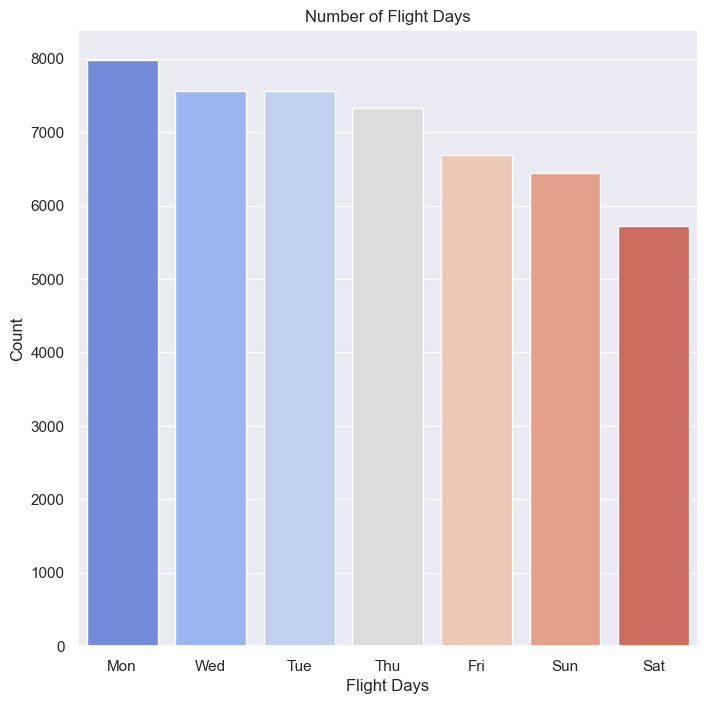

In [11]:
plt.figure(figsize=(8, 8))
sns.barplot(data = flight_day, x='flight_day', y='count', palette='coolwarm', hue='flight_day')
plt.xlabel('Flight Days')
plt.ylabel('Count')
plt.title('Number of Flight Days')
plt.show()

In [12]:
route = customer_booking['route'].value_counts().reset_index()

route

,route,count
0,AKLKUL,2620
1,PENTPE,912
2,MELSGN,833
3,ICNSIN,793
4,DMKKIX,729
...,...,...
794,CKGKNO,1
795,KBRWUH,1
796,JEDMFM,1
797,KTMTWU,1


In [13]:
booking_origin = customer_booking['booking_origin'].value_counts().reset_index()

booking_origin

,booking_origin,count
0,Australia,17691
1,Malaysia,7055
2,South Korea,4502
3,Japan,3819
4,China,3284
...,...,...
99,Ghana,1
100,Gibraltar,1
101,Guatemala,1
102,Algeria,1


Preprocessing the Data
-

Encoding Feature Variable Cloumns using LabelEncoder

In [14]:
le = LabelEncoder()

cat_col = ['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin']

for col in cat_col:
    customer_booking[col] = le.fit_transform(customer_booking[col])

Correlation Matrix
-

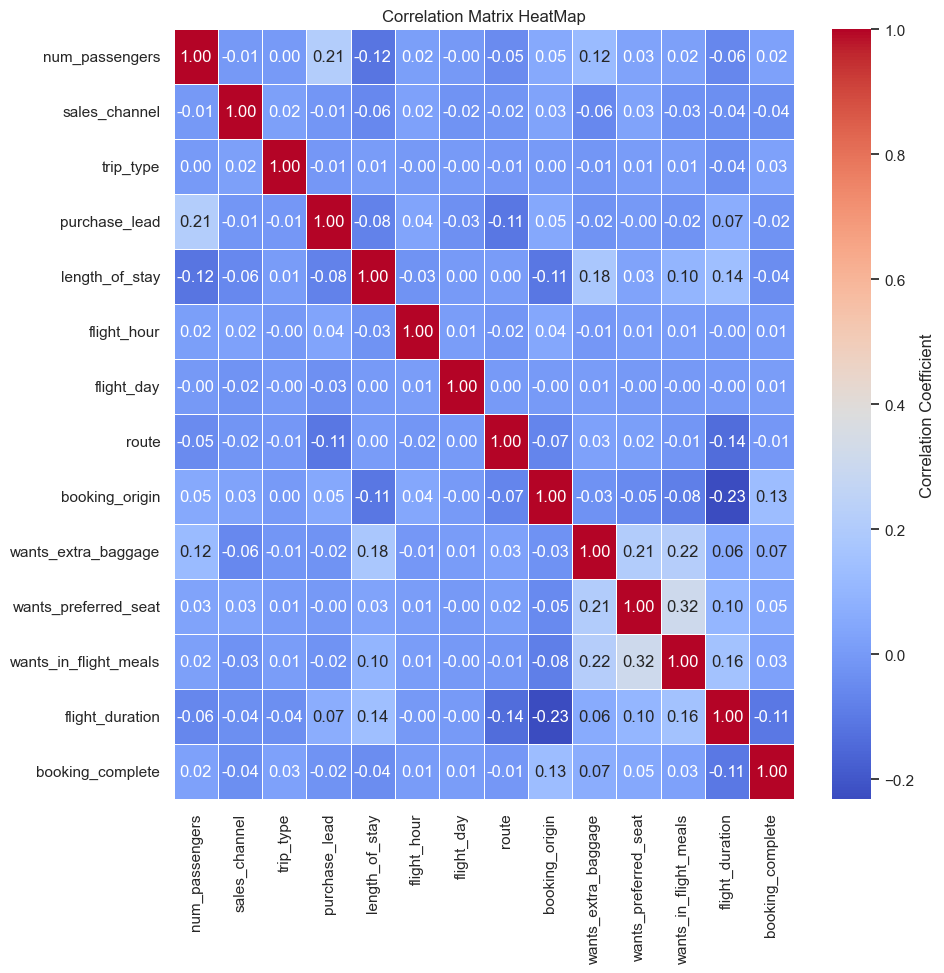

In [15]:
corr_matrix = customer_booking.corr()

plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix HeatMap')
plt.show()

Feature Selection and Data Splitting
-

In [16]:
x = customer_booking.drop(['booking_complete'], axis=1)
y = customer_booking['booking_complete']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [17]:
x_train.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration
48922,1,0,1,186,6,8,6,628,85,1,0,0,8.83
18543,1,0,2,180,30,4,3,619,50,1,1,1,8.83
24044,1,0,2,30,29,13,1,738,4,1,0,0,5.62
27574,1,0,2,13,3,13,1,368,99,0,1,0,6.62
42862,1,0,2,33,6,3,0,49,4,1,0,1,5.62


In [18]:
x_test.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration
48129,4,0,2,322,6,7,5,519,51,1,0,1,5.62
18081,1,0,2,29,17,5,4,606,17,0,0,0,5.00
35507,1,0,2,197,5,10,2,77,12,1,1,1,4.67
11737,2,0,2,165,25,8,2,366,4,1,1,0,8.58
1164,4,0,2,169,21,6,0,6,51,1,0,0,8.83


In [19]:
y_train.head()

48922    0
18543    1
24044    0
27574    0
42862    0
Name: booking_complete, dtype: int64

In [20]:
y_test.head()

48129    0
18081    0
35507    0
11737    1
1164     1
Name: booking_complete, dtype: int64

Feature Scaling
-

In [21]:
ss = StandardScaler()

x_train = ss.fit_transform(x_train)
x_test = ss.transform(x_test)

Model Training and Prediction
-

For training model we use RandomForestClassifier, DecisionTreeClassifier and KNeighborsClassifier

RandomForestClassifier
-

In [22]:
rfc = RandomForestClassifier(class_weight='balanced')

rfc.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [23]:
y_pred = rfc.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(9857,))

Checking Model Accuracy Score

In [24]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.2f}')



Model Accuracy: 0.85


Using Classification Report

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92      8377
           1       0.49      0.08      0.14      1480

    accuracy                           0.85      9857
   macro avg       0.68      0.53      0.53      9857
weighted avg       0.80      0.85      0.80      9857



DecisionTreeClassifier
-

In [26]:
dtc = DecisionTreeClassifier(class_weight='balanced')
dtc.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [27]:
y_pred = dtc.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 1], shape=(9857,))

Checking Model Accuracy Score

In [28]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.2f}')


Model Accuracy: 0.79


Using Classification Report

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.88      0.88      8377
           1       0.30      0.28      0.29      1480

    accuracy                           0.79      9857
   macro avg       0.59      0.58      0.59      9857
weighted avg       0.79      0.79      0.79      9857



Confusion Matrix
-

In [ ]:
print(confusion_matrix(y_test, y_pred))

[[7390  987]
 [1051  429]]


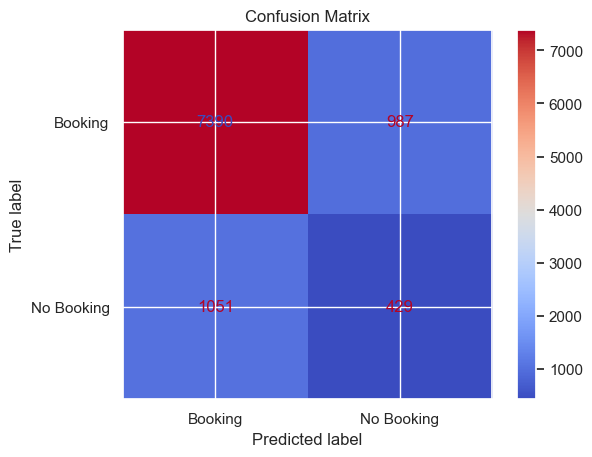

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Booking', 'No Booking'])
disp.plot(cmap='coolwarm')
plt.title('Confusion Matrix')
plt.show()